# 🔬 Notebook 03 — Feature Engineering

**Purpose**: Enrich features with domain knowledge, perform feature selection to remove redundant ones.

**Theory**: Lecture 02 — Feature engineering is often more impactful than choosing the right algorithm. Steps 4-6: Create New Features, Encode Categorical, Feature Selection.

**Important**: All engineering is done on raw data BEFORE scaling.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, sys, warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
os.makedirs('../plots', exist_ok=True)
sys.path.insert(0, '..')
from src.feature_engineer import *
print('Ready.')

Ready.


In [2]:
# Load raw data and split (same as NB02)
df = pd.read_csv('../data/nev_battery_charging.csv')
df = df.drop(columns=['timestamp']).drop_duplicates()
n = len(df)
train_end, val_end = int(n*0.70), int(n*0.85)
targets = ['cycle_degradation','over_temp_flag','over_voltage_flag']
df_train = df.iloc[:train_end].copy()
df_val = df.iloc[train_end:val_end].copy()
df_test = df.iloc[val_end:].copy()
print(f'Loaded: {df.shape}, Train={len(df_train)}, Val={len(df_val)}, Test={len(df_test)}')

Loaded: (1900, 20), Train=1330, Val=285, Test=285


## 1. Verify Existing Derived Features

Check if thermal_stress_index and aging_indicator are redundant with their source features.

Correlation analysis of derived features:
  battery_temp ↔ thermal_stress_index: 0.2467
  SOH ↔ aging_indicator:                -0.0024


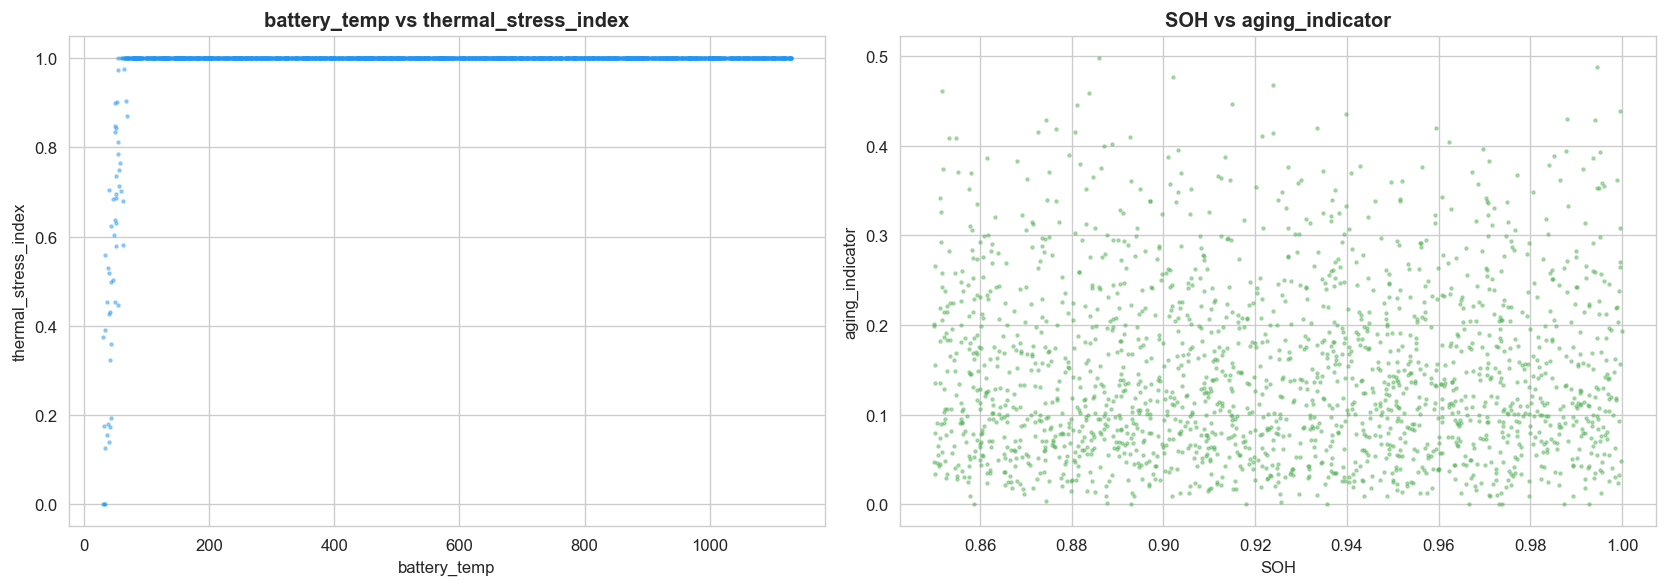

In [3]:
# Correlation check
print('Correlation analysis of derived features:')
print(f'  battery_temp ↔ thermal_stress_index: {df["battery_temp"].corr(df["thermal_stress_index"]):.4f}')
print(f'  SOH ↔ aging_indicator:                {df["SOH"].corr(df["aging_indicator"]):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['battery_temp'], df['thermal_stress_index'], s=3, alpha=0.4, c='#2196F3')
axes[0].set_xlabel('battery_temp'); axes[0].set_ylabel('thermal_stress_index')
axes[0].set_title('battery_temp vs thermal_stress_index', fontweight='bold')

axes[1].scatter(df['SOH'], df['aging_indicator'], s=3, alpha=0.4, c='#4CAF50')
axes[1].set_xlabel('SOH'); axes[1].set_ylabel('aging_indicator')
axes[1].set_title('SOH vs aging_indicator', fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/fe_derived_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

bt_tsi_corr = abs(df['battery_temp'].corr(df['thermal_stress_index']))
if bt_tsi_corr > 0.95:
    print(f'\n⚠️ Correlation {bt_tsi_corr:.4f} > 0.95 → DROP battery_temp, KEEP thermal_stress_index (normalized 0-1)')

## 2. Engineer New Features

All features below are grounded in battery physics and electrochemistry domain knowledge.

### 2a. Delta Internal Resistance

Change from training baseline IR → direct proxy for cumulative battery aging.

Training IR baseline: 0.089445


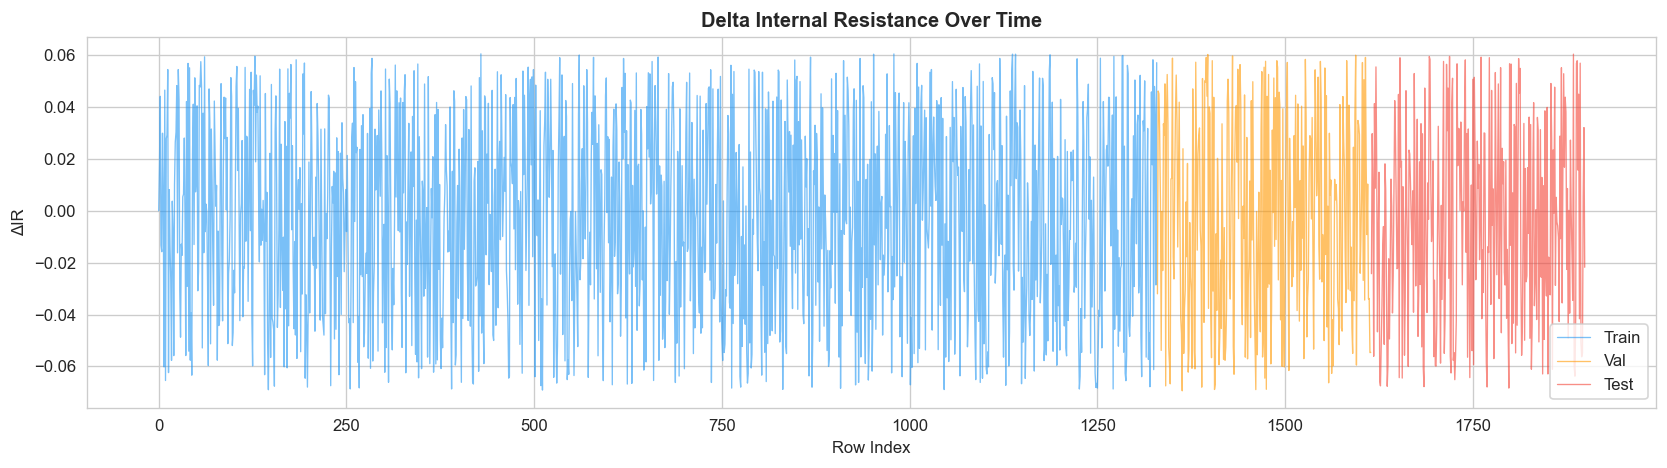

In [4]:
# Delta internal resistance
baseline_ir = df_train['internal_resistance'].iloc[0]
print(f'Training IR baseline: {baseline_ir:.6f}')

df_train_eng = add_delta_internal_resistance(df_train, baseline_ir)
df_val_eng = add_delta_internal_resistance(df_val, baseline_ir)
df_test_eng = add_delta_internal_resistance(df_test, baseline_ir)

fig, ax = plt.subplots(figsize=(14, 4))
for d, lbl, c in [(df_train_eng,'Train','#2196F3'),(df_val_eng,'Val','#FF9800'),(df_test_eng,'Test','#F44336')]:
    ax.plot(d.index, d['delta_internal_resistance'], c=c, alpha=0.6, linewidth=0.8, label=lbl)
ax.set_xlabel('Row Index'); ax.set_ylabel('ΔIR')
ax.set_title('Delta Internal Resistance Over Time', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/fe_delta_ir.png', dpi=150, bbox_inches='tight')
plt.show()

### 2b. SOC Range Rolling Window

Captures cycling aggressiveness — batteries cycled 0-100% degrade faster than 20-80%.

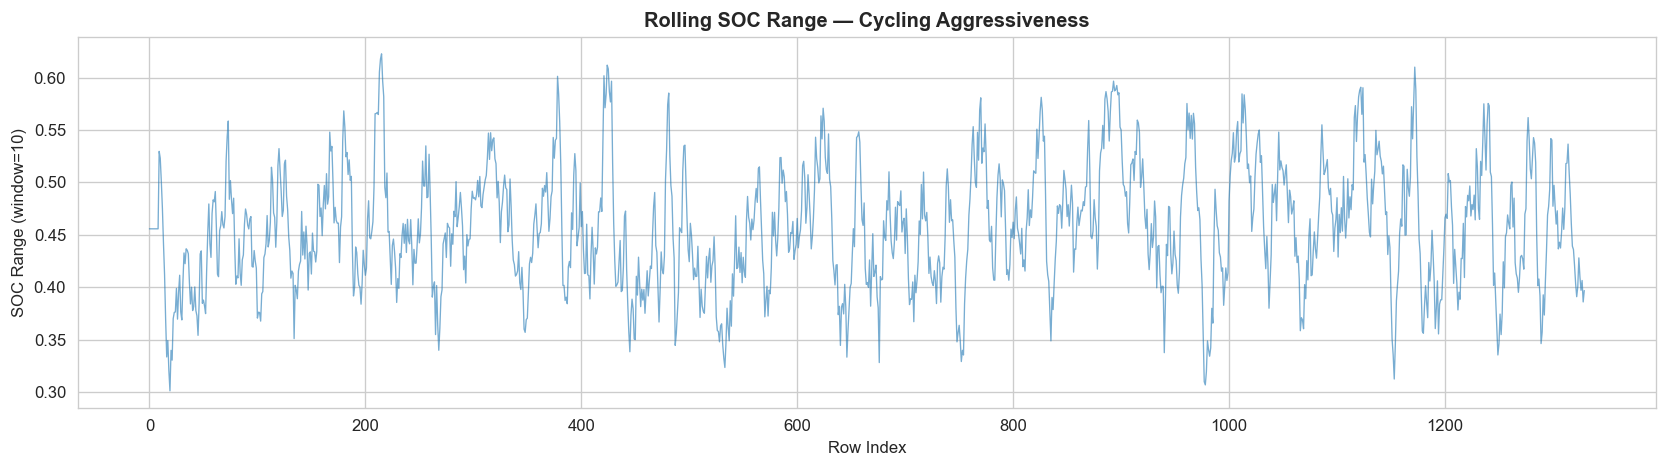

In [5]:
# SOC range rolling
df_train_eng = add_soc_range_rolling(df_train_eng, window=10)
df_val_eng = add_soc_range_rolling(df_val_eng, window=10)
df_test_eng = add_soc_range_rolling(df_test_eng, window=10)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train_eng.index, df_train_eng['soc_range_rolling'], alpha=0.6, linewidth=0.8)
ax.set_xlabel('Row Index'); ax.set_ylabel('SOC Range (window=10)')
ax.set_title('Rolling SOC Range — Cycling Aggressiveness', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/fe_soc_range_rolling.png', dpi=150, bbox_inches='tight')
plt.show()

### 2c. Thermal Acceleration

dT/dt × battery_temp — high temp + rapid change is more damaging than either alone.

In [6]:
# Thermal acceleration
df_train_eng = add_thermal_acceleration(df_train_eng)
df_val_eng = add_thermal_acceleration(df_val_eng)
df_test_eng = add_thermal_acceleration(df_test_eng)
print(f'Thermal acceleration range: {df_train_eng["thermal_acceleration"].min():.2f} to {df_train_eng["thermal_acceleration"].max():.2f}')

Thermal acceleration range: -9.72 to 1758.26


### 2d. Voltage Efficiency

action_voltage / terminal_voltage — deviation from 1.0 indicates impedance stress.

In [7]:
# Voltage efficiency
df_train_eng = add_voltage_efficiency(df_train_eng)
df_val_eng = add_voltage_efficiency(df_val_eng)
df_test_eng = add_voltage_efficiency(df_test_eng)
print(f'Voltage efficiency range: {df_train_eng["voltage_efficiency"].min():.4f} to {df_train_eng["voltage_efficiency"].max():.4f}')

Voltage efficiency range: 0.9501 to 1.0462


### 2e. Polynomial Features

Squared terms for non-linear degradation relationships. Battery degradation accelerates exponentially.

In [8]:
# Polynomial features
df_train_eng = add_polynomial_features(df_train_eng)
df_val_eng = add_polynomial_features(df_val_eng)
df_test_eng = add_polynomial_features(df_test_eng)
print(f'Columns after engineering: {len(df_train_eng.columns)}')
print(f'New columns: {[c for c in df_train_eng.columns if c not in df_train.columns]}')

Columns after engineering: 27
New columns: ['delta_internal_resistance', 'soc_range_rolling', 'thermal_acceleration', 'voltage_efficiency', 'internal_resistance_sq', 'thermal_stress_index_sq', 'aging_indicator_sq']


### 2f. Drop Redundant Features

In [9]:
# Drop battery_temp (redundant with thermal_stress_index)
df_train_eng = drop_redundant_features(df_train_eng, ['battery_temp'])
df_val_eng = drop_redundant_features(df_val_eng, ['battery_temp'])
df_test_eng = drop_redundant_features(df_test_eng, ['battery_temp'])
print(f'Columns after dropping redundant: {len(df_train_eng.columns)}')

Columns after dropping redundant: 26


## 3. Engineered Features Overview

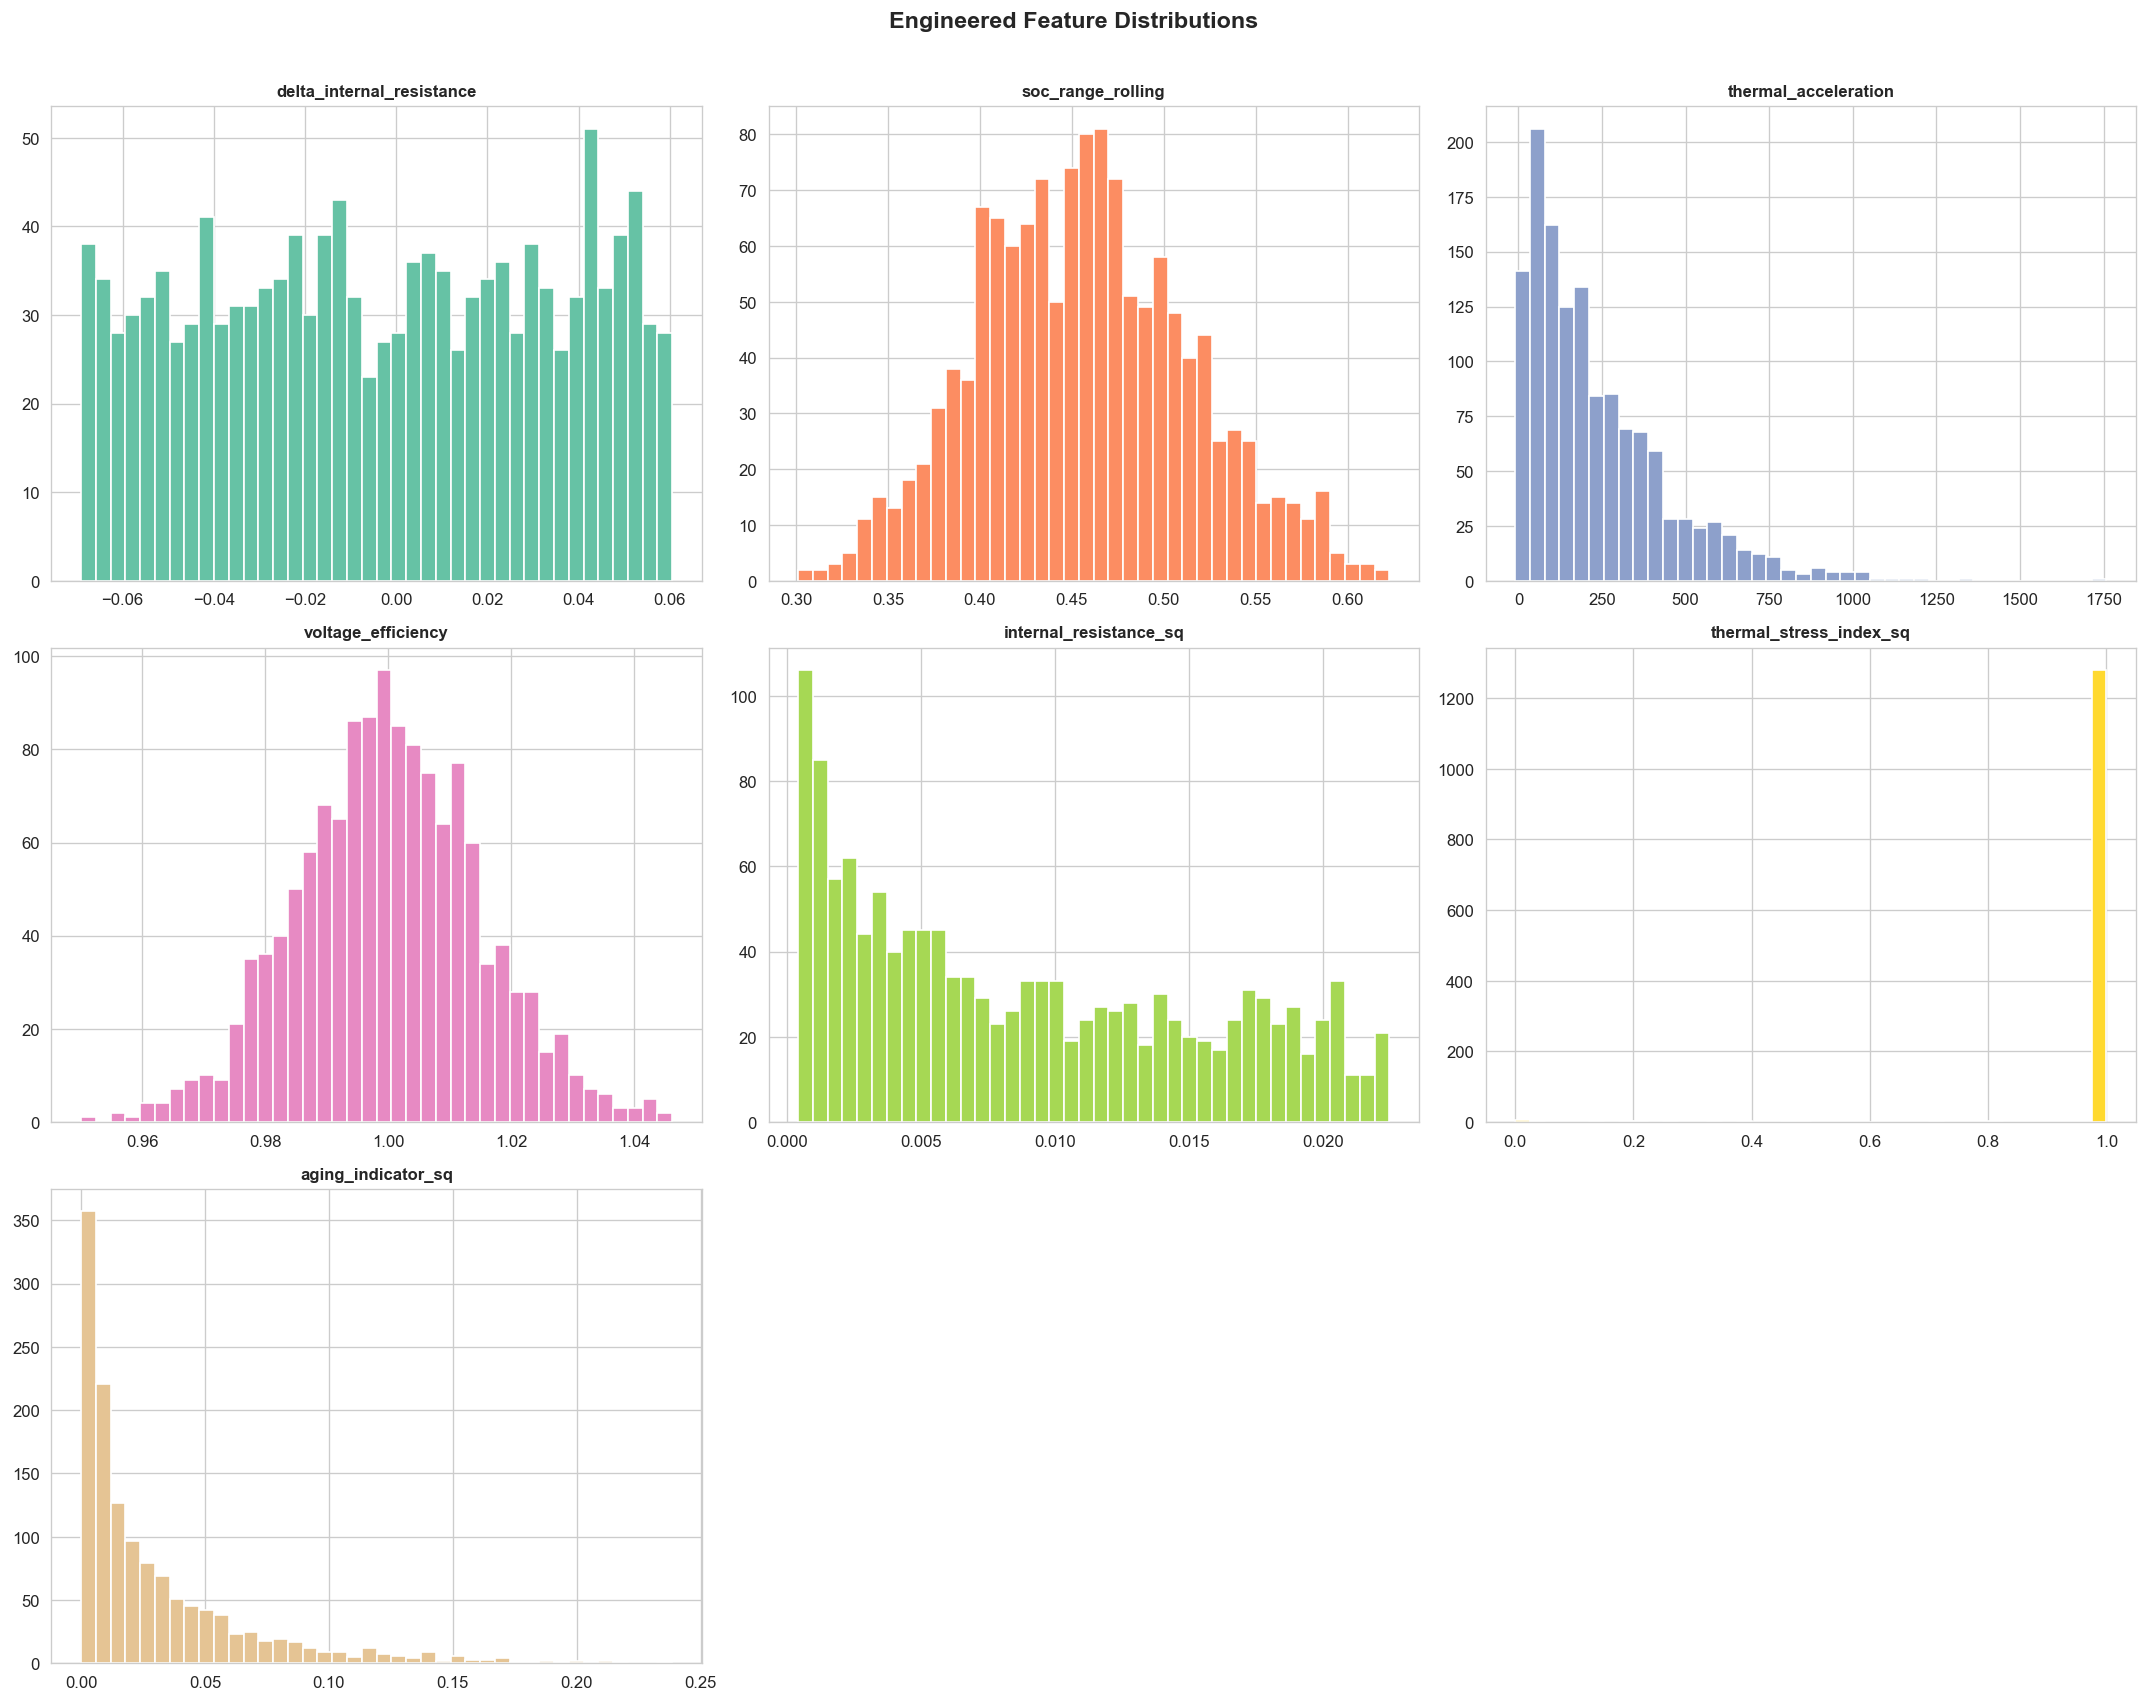

In [10]:
# Summary of all engineered features
eng_cols = ['delta_internal_resistance','soc_range_rolling','thermal_acceleration',
            'voltage_efficiency','internal_resistance_sq','thermal_stress_index_sq','aging_indicator_sq']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for i, col in enumerate(eng_cols):
    ax = axes[i//3, i%3]
    ax.hist(df_train_eng[col].dropna(), bins=40, color=plt.cm.Set2(i/len(eng_cols)), edgecolor='white')
    ax.set_title(col, fontweight='bold', fontsize=10)
for j in range(len(eng_cols), 9):
    axes[j//3, j%3].set_visible(False)
plt.suptitle('Engineered Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/fe_engineered_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Selection — Filter Method

**Theory**: Lecture 05 Filter Methods — Use statistical properties (correlation). Fast and easy.

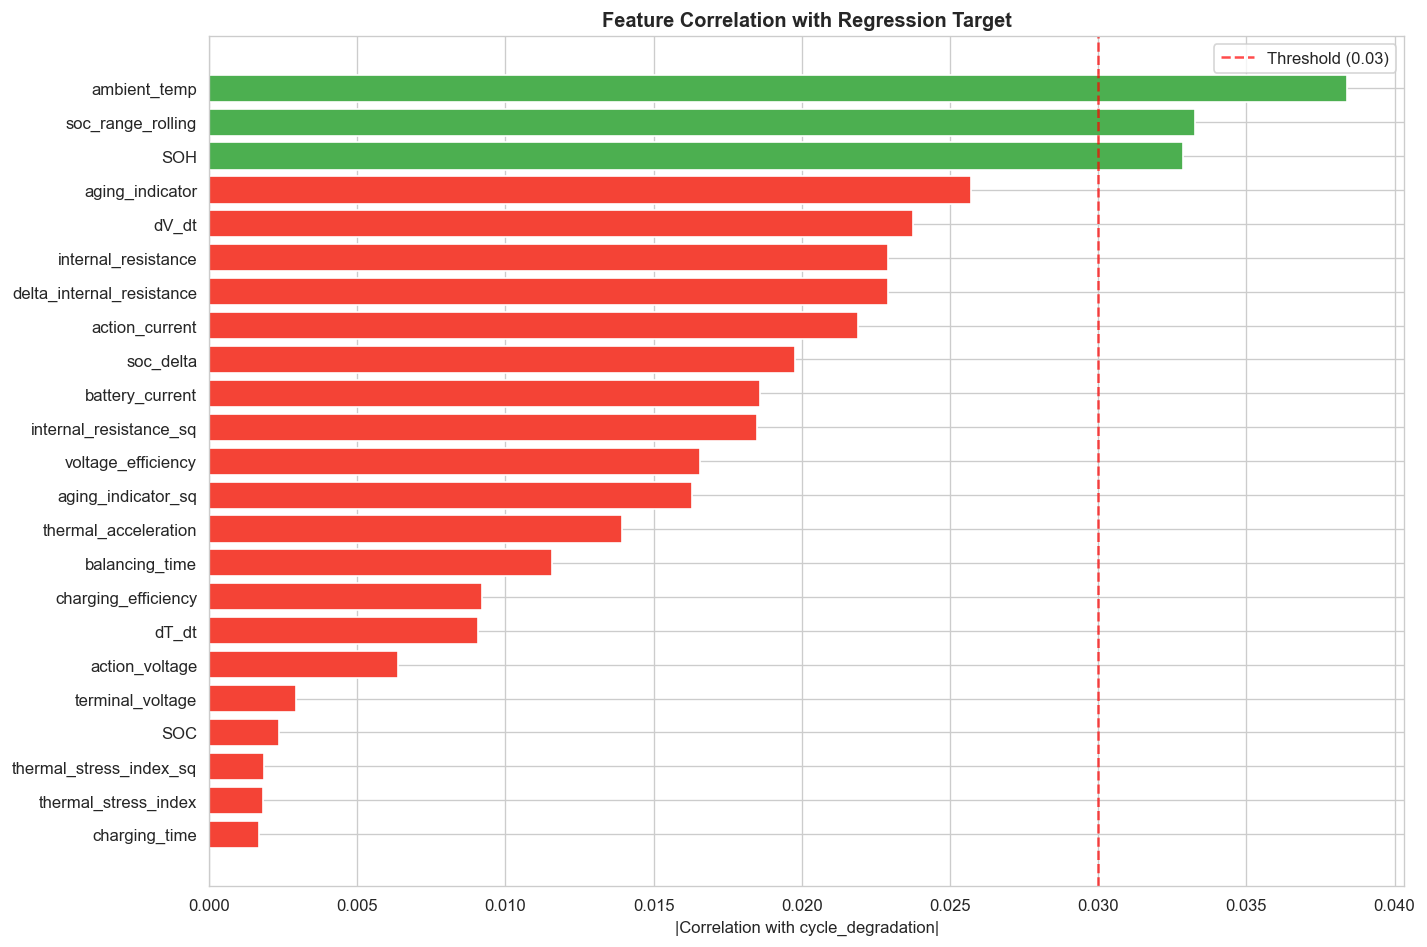


Weak features (|corr| < 0.03): ['aging_indicator', 'dV_dt', 'internal_resistance', 'delta_internal_resistance', 'action_current', 'soc_delta', 'battery_current', 'internal_resistance_sq', 'voltage_efficiency', 'aging_indicator_sq', 'thermal_acceleration', 'balancing_time', 'charging_efficiency', 'dT_dt', 'action_voltage', 'terminal_voltage', 'SOC', 'thermal_stress_index_sq', 'thermal_stress_index', 'charging_time']


In [11]:
# Filter method: correlation with target
X_eng = df_train_eng.drop(columns=targets)
corr_with_target = X_eng.corrwith(df_train_eng['cycle_degradation']).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#F44336' if v < 0.03 else '#4CAF50' for v in corr_with_target.values]
ax.barh(range(len(corr_with_target)), corr_with_target.values, color=colors)
ax.set_yticks(range(len(corr_with_target)))
ax.set_yticklabels(corr_with_target.index)
ax.axvline(x=0.03, color='red', linestyle='--', alpha=0.7, label='Threshold (0.03)')
ax.set_xlabel('|Correlation with cycle_degradation|')
ax.set_title('Feature Correlation with Regression Target', fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../plots/fe_correlation_filter.png', dpi=150, bbox_inches='tight')
plt.show()

weak = corr_with_target[corr_with_target < 0.03].index.tolist()
print(f'\nWeak features (|corr| < 0.03): {weak}')

## 5. Feature Selection — Wrapper Method (RFE)

**Theory**: Lecture 05 Wrapper Methods — Train model with feature subsets (RFE). Considers feature interactions. High accuracy but computationally expensive.

In [12]:
# Prepare data for RFE
X_rfe = df_train_eng.drop(columns=targets)
y_rfe = np.log1p(df_train_eng['cycle_degradation'])

scaler_rfe = StandardScaler()
X_rfe_scaled = scaler_rfe.fit_transform(X_rfe)

# RFE with RandomForest
n_select = min(15, X_rfe.shape[1])
estimator = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rfe = RFE(estimator, n_features_to_select=n_select, step=1)
rfe.fit(X_rfe_scaled, y_rfe)

selected = [col for col, rank in zip(X_rfe.columns, rfe.ranking_) if rank == 1]
rejected = [col for col, rank in zip(X_rfe.columns, rfe.ranking_) if rank > 1]

print(f'Selected features ({len(selected)}):')
for i, f in enumerate(selected, 1):
    print(f'  {i}. {f}')
print(f'\nRejected features ({len(rejected)}):')
for f in rejected:
    print(f'  ✗ {f}')

Selected features (15):
  1. SOH
  2. battery_current
  3. ambient_temp
  4. action_current
  5. action_voltage
  6. dV_dt
  7. soc_delta
  8. charging_efficiency
  9. charging_time
  10. balancing_time
  11. soc_range_rolling
  12. thermal_acceleration
  13. voltage_efficiency
  14. internal_resistance_sq
  15. aging_indicator_sq

Rejected features (8):
  ✗ SOC
  ✗ terminal_voltage
  ✗ internal_resistance
  ✗ dT_dt
  ✗ thermal_stress_index
  ✗ aging_indicator
  ✗ delta_internal_resistance
  ✗ thermal_stress_index_sq


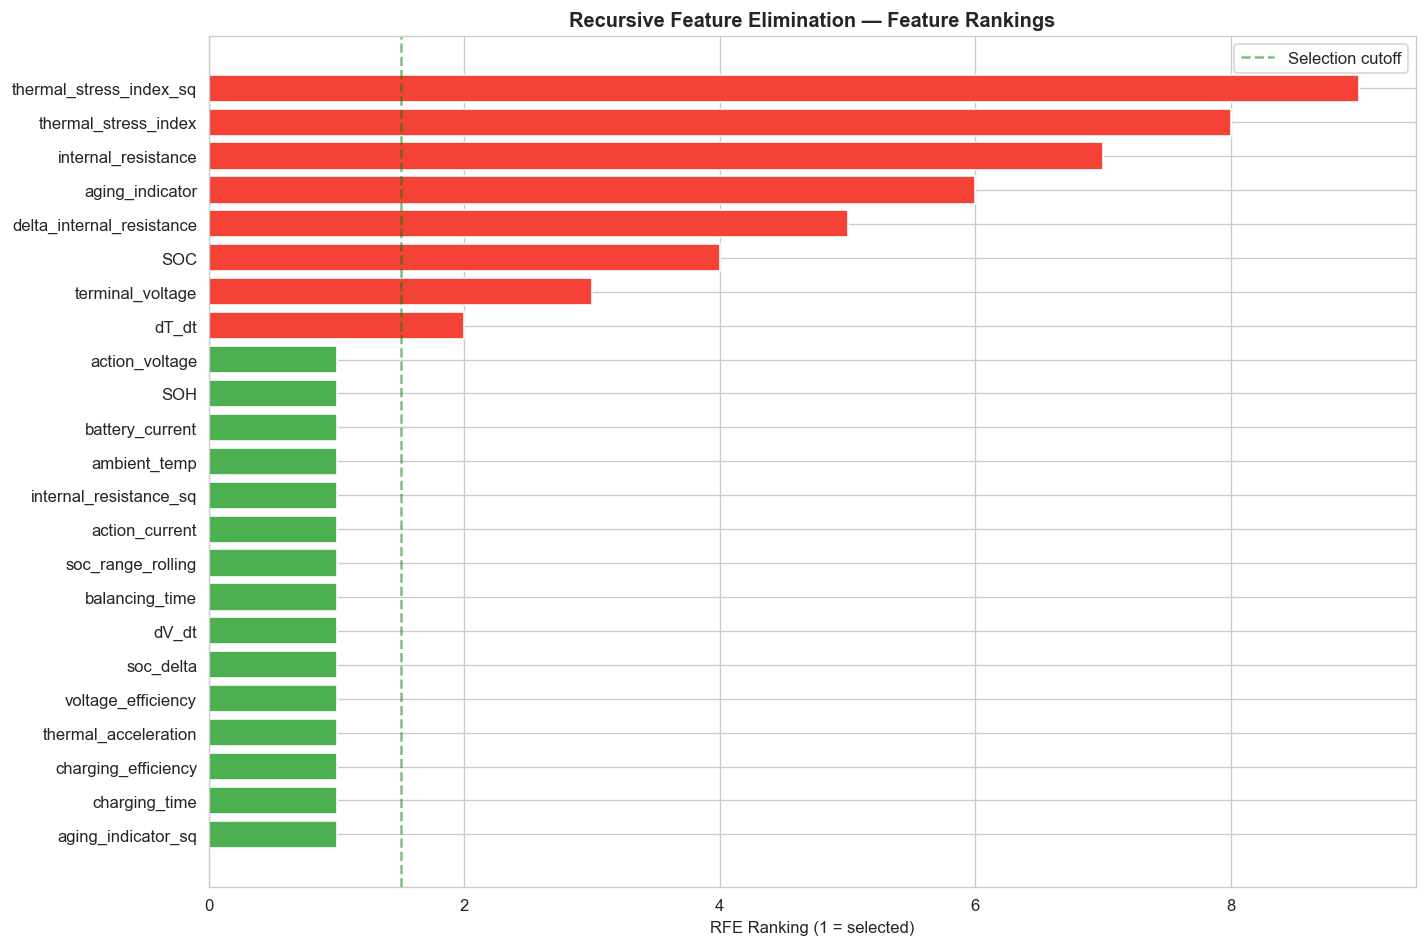

In [13]:
# Visualize RFE ranking
rankings = pd.Series(rfe.ranking_, index=X_rfe.columns).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#4CAF50' if r == 1 else '#F44336' for r in rankings.values]
ax.barh(range(len(rankings)), rankings.values, color=colors)
ax.set_yticks(range(len(rankings)))
ax.set_yticklabels(rankings.index)
ax.set_xlabel('RFE Ranking (1 = selected)')
ax.set_title('Recursive Feature Elimination — Feature Rankings', fontweight='bold')
ax.axvline(x=1.5, color='green', linestyle='--', alpha=0.5, label='Selection cutoff')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/fe_rfe_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Final Feature Set

In [14]:
# Save selected feature columns
with open('../models/feature_columns.json', 'w') as f:
    json.dump(selected, f, indent=2)
print(f'Saved {len(selected)} selected features to models/feature_columns.json')
print(f'Features: {selected}')

Saved 15 selected features to models/feature_columns.json
Features: ['SOH', 'battery_current', 'ambient_temp', 'action_current', 'action_voltage', 'dV_dt', 'soc_delta', 'charging_efficiency', 'charging_time', 'balancing_time', 'soc_range_rolling', 'thermal_acceleration', 'voltage_efficiency', 'internal_resistance_sq', 'aging_indicator_sq']


## 📋 Feature Engineering Summary

| Feature | Type | Source | Rationale |
|---------|------|--------|----------|
| delta_internal_resistance | Engineered | internal_resistance - baseline | Cumulative aging proxy |
| soc_range_rolling | Engineered | Rolling SOC window | Cycling aggressiveness |
| thermal_acceleration | Engineered | dT_dt × battery_temp | Compound thermal stress |
| voltage_efficiency | Engineered | action_V / terminal_V | Impedance stress signal |
| *_sq (3 features) | Polynomial | Squared terms | Non-linear degradation curves |
| battery_temp | Dropped | Redundant with thermal_stress_index | >0.95 correlation |

**Selection method**: RFE with RandomForest → top 15 features selected and saved.